In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors


In [2]:
meas = pd.read_csv("Measures.csv")
nat = pd.read_csv("National_results.csv")
ques = pd.read_csv("Questions.csv")
rep = pd.read_csv("Reports.csv")
resp = pd.read_csv("Responses.csv")
state_res = pd.read_csv("State_Results.csv")
states = pd.read_csv("States.csv")


In [3]:
print(meas.isnull().sum())
print(nat.isnull().sum())
print(ques.isnull().sum())
print(rep.isnull().sum())
print(resp.isnull().sum())
print(state_res.isnull().sum())
print(states.isnull().sum())

Measure ID    0
Measure       0
Type          0
dtype: int64
Release Period           0
Measure ID               0
Bottom-box Percentage    0
Middle-box Percentage    0
Top-box Percentage       0
dtype: int64
Question Num         0
Measure ID           0
Question             0
Bottom-box Answer    0
Middle-box Answer    2
Top-box Answer       0
dtype: int64
Release Period    0
Start Date        0
End Date          0
dtype: int64
Release Period       0
State                0
Facility ID          0
Completed Surveys    0
Response Rate (%)    0
dtype: int64
Release Period           0
State                    0
Measure ID               0
Bottom-box Percentage    0
Middle-box Percentage    0
Top-box Percentage       0
dtype: int64
State         0
State Name    0
Region        0
dtype: int64


In [4]:
print("meas:", meas.shape)
print("nat:", nat.shape)
print("ques:", ques.shape)
print("rep:", rep.shape)
print("resp:", resp.shape)
print("state_res:", state_res.shape)
print("states:", states.shape)

meas: (10, 3)
nat: (90, 5)
ques: (19, 6)
rep: (9, 3)
resp: (43219, 5)
state_res: (4580, 6)
states: (51, 3)


In [5]:
print("meas:", meas.columns.tolist())
print("nat:", nat.columns.tolist())
print("ques:", ques.columns.tolist())
print("rep:", rep.columns.tolist())
print("resp:", resp.columns.tolist())
print("state_res:", state_res.columns.tolist())
print("states:", states.columns.tolist())

meas: ['Measure ID', 'Measure', 'Type']
nat: ['Release Period', 'Measure ID', 'Bottom-box Percentage', 'Middle-box Percentage', 'Top-box Percentage']
ques: ['Question Num', 'Measure ID', 'Question', 'Bottom-box Answer', 'Middle-box Answer', 'Top-box Answer']
rep: ['Release Period', 'Start Date', 'End Date']
resp: ['Release Period', 'State', 'Facility ID', 'Completed Surveys', 'Response Rate (%)']
state_res: ['Release Period', 'State', 'Measure ID', 'Bottom-box Percentage', 'Middle-box Percentage', 'Top-box Percentage']
states: ['State', 'State Name', 'Region']


In [6]:
meas

,Measure ID,Measure,Type
0,H_COMP_1,Communication with Nurses,Composite Measure
1,H_COMP_2,Communication with Doctors,Composite Measure
2,H_COMP_3,Responsiveness of Hospital Staff,Composite Measure
3,H_COMP_5,Communication about Medicines,Composite Measure
4,H_COMP_6,Discharge Information,Composite Measure
5,H_COMP_7,Care Transition,Composite Measure
6,H_CLEAN_HSP,Cleanliness of Hospital Environment,Individual Item
7,H_QUIET_HSP,Quietness of Hospital Environment,Individual Item
8,H_HSP_RATING,Overall Hospital Rating,Global Item
9,H_RECMND,Willingness to Recommend the Hospital,Global Item


In [7]:
meas["Measure"].value_counts().index

Index(['Communication with Nurses', 'Communication with Doctors',
       'Responsiveness of Hospital Staff', 'Communication about Medicines',
       'Discharge Information', 'Care Transition',
       'Cleanliness of Hospital Environment',
       'Quietness of Hospital Environment', 'Overall Hospital Rating',
       'Willingness to Recommend the Hospital'],
      dtype='object', name='Measure')

In [8]:
nat.head()

,Release Period,Measure ID,Bottom-box Percentage,Middle-box Percentage,Top-box Percentage
0,07_2015,H_CLEAN_HSP,8,18,74
1,07_2015,H_COMP_1,4,17,79
2,07_2015,H_COMP_2,4,14,82
3,07_2015,H_COMP_3,9,23,68
4,07_2015,H_COMP_5,18,17,65


In [9]:
red = "#ff5500"
blue = "#00338d"
grey = "#666666"

In [10]:
nat['Year'] = pd.to_datetime(nat['Release Period'].str.split('_').str[1], format='%Y').dt.year

In [11]:
blued = "#002244"
bluel = "#0146c7"
red = "#bf3242"

In [12]:
calc_data = nat.groupby(['Year', 'Measure ID'])['Top-box Percentage'].mean().unstack()
calc_data

Measure ID,H_CLEAN_HSP,H_COMP_1,H_COMP_2,H_COMP_3,H_COMP_5,H_COMP_6,H_COMP_7,H_HSP_RATING,H_QUIET_HSP,H_RECMND
Year,,,,,,,,,,
2015,74.0,79.0,82.0,68.0,65.0,86.0,52.0,71.0,62.0,71.0
2016,74.0,80.0,82.0,68.0,65.0,87.0,52.0,72.0,62.0,71.0
2017,74.0,80.0,82.0,69.0,65.0,87.0,52.0,73.0,63.0,72.0
2018,75.0,80.0,82.0,70.0,66.0,87.0,53.0,73.0,62.0,72.0
2019,75.0,81.0,81.0,70.0,66.0,87.0,53.0,73.0,62.0,72.0
2020,76.0,81.0,82.0,70.0,66.0,87.0,54.0,73.0,62.0,72.0
2021,76.0,81.0,82.0,70.0,66.0,87.0,54.0,73.0,62.0,72.0
2022,73.0,80.0,80.0,67.0,63.0,86.0,52.0,72.0,63.0,71.0
2023,72.0,79.0,79.0,65.0,61.0,86.0,51.0,70.0,62.0,69.0


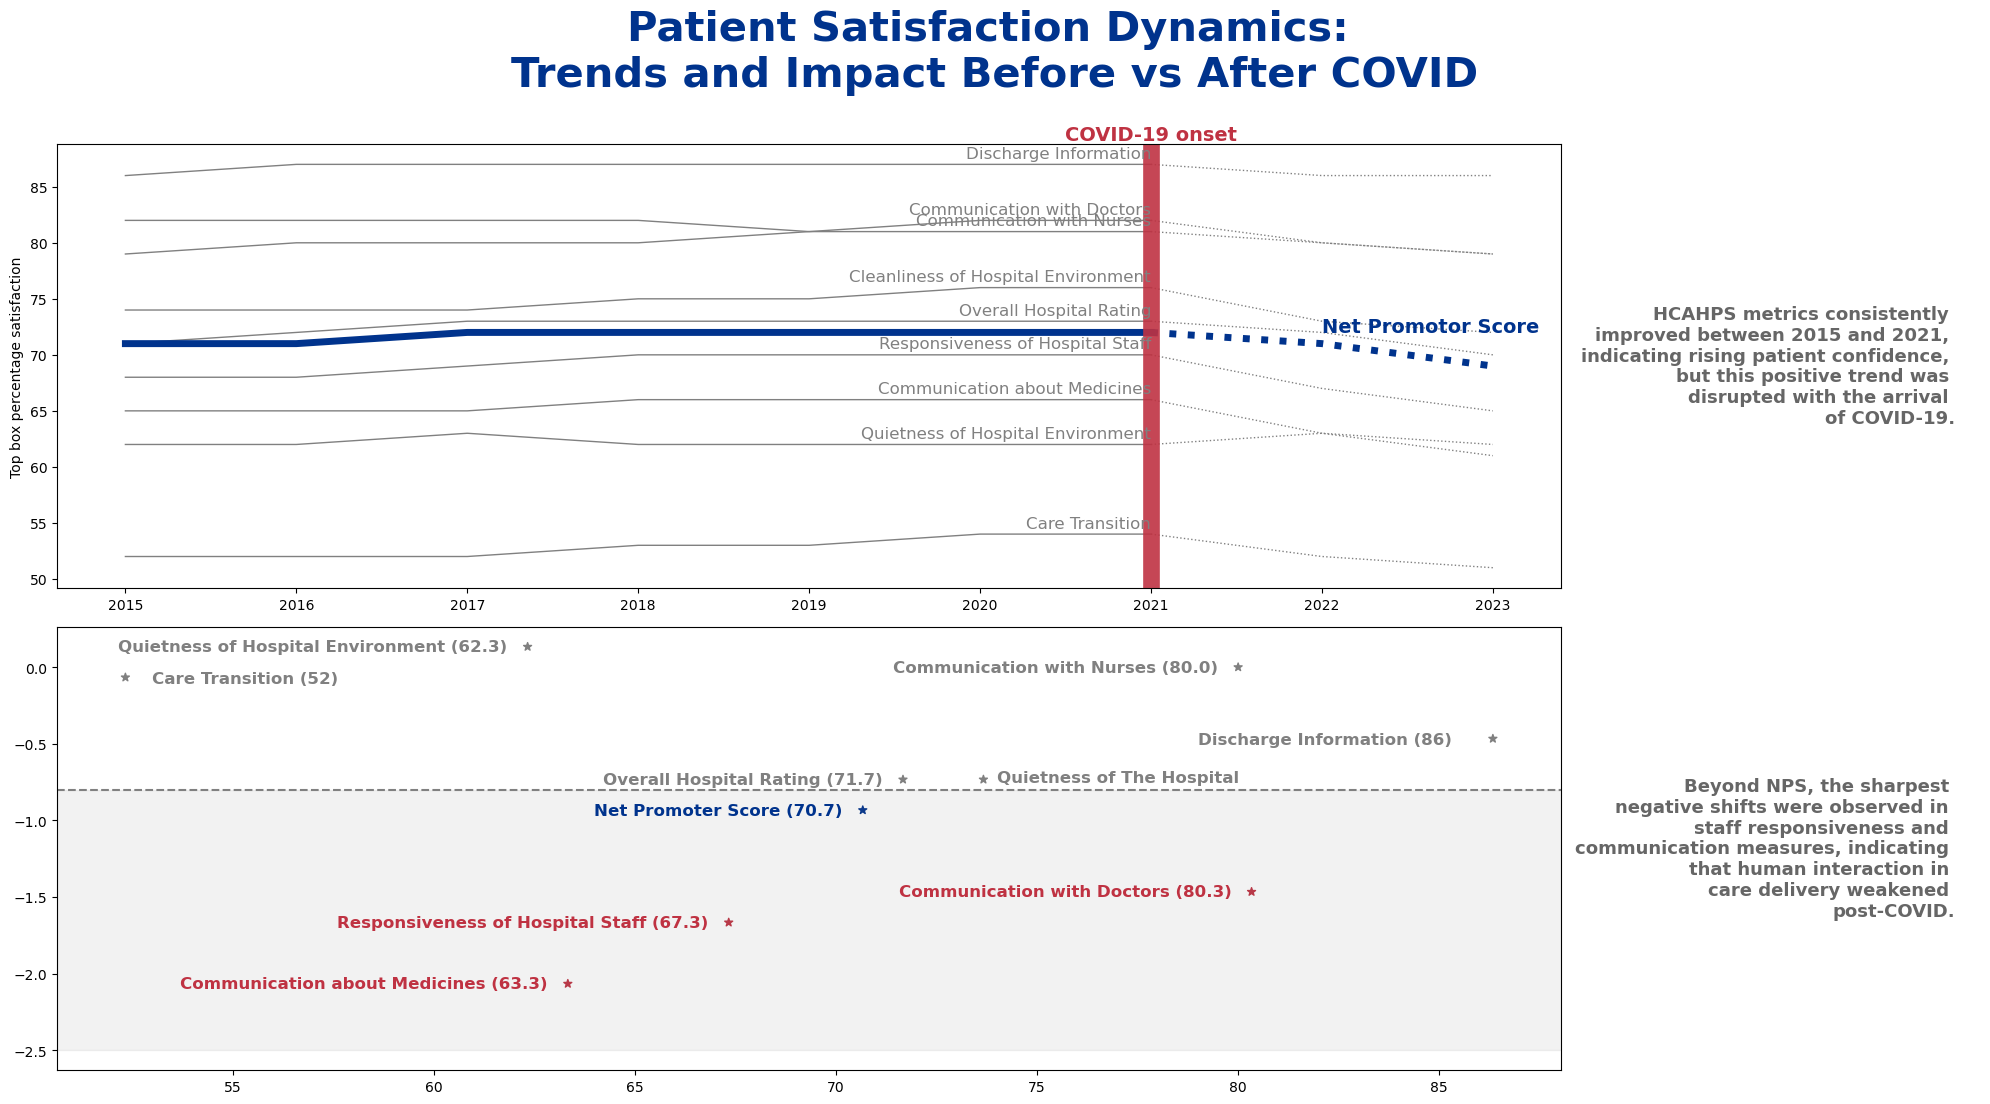

In [174]:
fig = plt.figure(figsize=(20,11), facecolor="white",dpi=100)

ax1 = plt.subplot2grid((2,5),(0,0), colspan=4)
ax2 = plt.subplot2grid((2,5),(0,4))
ax2.set_xticks([]); ax2.set_yticks([])
ax3 = plt.subplot2grid((2,5),(1,0), colspan=4)
ax4 = plt.subplot2grid((2,5),(1,4))
ax4.set_xticks([]); ax4.set_yticks([])

nat['Year'] = pd.to_datetime(nat['Release Period'].str.split('_').str[1], format='%Y').dt.year; nat['Top-box Percentage'] = pd.to_numeric(nat['Top-box Percentage'], errors='coerce')
plot_df = nat.groupby(['Year','Measure ID'])['Top-box Percentage'].mean().unstack(); measure_map = dict(zip(meas['Measure ID'], meas['Measure']))

years = plot_df.index; pre_covid = years[years <= 2021]; post_covid = years[years >= 2021]

for col in plot_df.columns:
    label = measure_map.get(col,col); color = blue if col=='H_RECMND' else "grey"; linewidth = 5 if col=='H_RECMND' else 1; alpha = 1.0
    ax1.plot(pre_covid, plot_df.loc[pre_covid,col], color=color, linewidth=linewidth, alpha=alpha)
    ax1.plot(post_covid, plot_df.loc[post_covid,col], color=color, linewidth=linewidth, alpha=alpha, linestyle=':')
    if col!='H_RECMND': ax1.text(2021, plot_df.loc[2021,col]+0.3, label, fontsize=12, color=color, ha='right', va='bottom', alpha=alpha)

ax1.axvline(x=2021, color=red, linewidth=12, alpha=0.9); ax1.text(2021, ax1.get_ylim()[1], 'COVID-19 onset', color=red, fontweight='bold', ha='center', va='bottom', fontsize=14)
ax1.text(2022,72,"Net Promotor Score", fontsize=14, color=blue, fontweight="bold")
ax1.set_ylabel('Top box percentage satisfaction'); ax1.set_xticks(years)

nat['Top-box Percentage'] = pd.to_numeric(nat['Top-box Percentage'], errors='coerce')
current_perf = nat[nat['Year'] >= 2021].groupby('Measure ID')['Top-box Percentage'].mean(); baseline_perf = nat[nat['Year'] < 2020].groupby('Measure ID')['Top-box Percentage'].mean()
scatter_df = pd.concat([current_perf, baseline_perf], axis=1); scatter_df.columns = ['Performance','Baseline']; scatter_df['Impact'] = scatter_df['Performance'] - scatter_df['Baseline']
scatter_df = scatter_df.reset_index().merge(meas[['Measure ID','Measure']], on='Measure ID')
scatter_df['Measure'] = scatter_df['Measure'].replace({'Willingness to Recommend the Hospital':'Net Promoter Score'})

colors = [blue if m=='Net Promoter Score' else (red if y < -0.8 else 'grey') for m,y in zip(scatter_df['Measure'], scatter_df['Impact'])]
ax3.scatter(scatter_df['Performance'], scatter_df['Impact'], color=colors, marker='*')
x_vals = scatter_df['Performance'].tolist(); y_vals = scatter_df['Impact'].tolist(); measures = scatter_df['Measure'].tolist(); texts = [f"{m} ({round(p,1)})" for m,p in zip(measures, scatter_df['Performance'])]
for x,y,m,t,c in zip(x_vals,y_vals,measures,texts,colors):
    if m not in ['Cleanliness of Hospital Environment','Discharge Information',"Care Transition"]:
        ax3.text(x-0.5, y, t, fontsize=12, color=c, fontweight='bold', ha="right", va="center")
ax3.axhline(scatter_df['Impact'].mean(), linestyle='--', color="grey")
ax3.text(74,-0.75,"Quietness of The Hospital", fontsize=12, color="grey", fontweight="bold")
ax3.text(79,-0.5,"Discharge Information (86)", fontsize=12, color="grey", fontweight="bold")
ax3.text(53,-0.1,"Care Transition (52)", fontsize=12, color="grey", fontweight="bold")
ax3.axhspan(-0.8, -2.5, xmin=0, xmax=90/ax3.get_xlim()[1], color="grey", alpha=0.1)
# ax3.set_xlabel(""); ax3.set_ylabel("")
fig.suptitle("Patient Satisfaction Dynamics: \nTrends and Impact Before vs After COVID",x=0.5,y=1,fontsize=30,color=blue,ha="center", fontweight="bold")

ax2.text(0.9,0.5,"HCAHPS metrics consistently \nimproved between 2015 and 2021, \nindicating rising patient confidence, \nbut this positive trend was \ndisrupted with the arrival \nof COVID-19.",
         va='center',ha="right",color=grey, fontweight='bold',fontsize=13)
for spine in ax2.spines.values(): spine.set_visible(False)
ax4.text(0.9,0.5,"Beyond NPS, the sharpest \nnegative shifts were observed in \nstaff responsiveness and \ncommunication measures, indicating \nthat human interaction in \ncare delivery weakened \npost-COVID.",
         va='center',ha="right",color=grey, fontweight='bold',fontsize=13)
for spine in ax4.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
temp = resp.copy()

temp = temp[temp['Completed Surveys'] != 'Not Available']
temp = temp[temp['Response Rate (%)'] != 'Not Available']

def map_vol(val):
    val = str(val).lower()
    if 'fewer than 100' in val: return 99
    if '300 or more' in val: return 301
    if 'between 100 and 299' in val: return 200
    if 'fewer than 50' in val: return 49
    return val

temp['Comp'] = pd.to_numeric(temp['Completed Surveys'].apply(map_vol), errors='coerce')
temp['Rate'] = pd.to_numeric(temp['Response Rate (%)'], errors='coerce') / 100

temp = temp.dropna(subset=['Comp', 'Rate'])
temp = temp[temp['Rate'] > 0]

temp['Mail'] = temp['Comp'] / temp['Rate']
temp['Year'] = temp['Release Period'].str.split('_').str[1]

y_stats = temp.groupby('Year').agg({
    'Comp': 'sum', 
    'Mail': 'sum'
})

y_stats['W_Rate'] = (y_stats['Comp'] / y_stats['Mail']) * 100

y_stats = y_stats.rename(columns={
    'Comp': 'Total_Completed',
    'Mail': 'Total_Mailed'
})

In [18]:
def map_vol(val):
    val = str(val).lower()
    if 'fewer than 100' in val: return 99
    if '300 or more' in val: return 301
    if 'between 100 and 299' in val: return 200
    if 'fewer than 50' in val: return 49
    return val

resp_clean = resp[resp['Completed Surveys'] != 'Not Available'].copy()
resp_clean = resp_clean[resp_clean['Response Rate (%)'] != 'Not Available']

resp_clean['Comp'] = pd.to_numeric(resp_clean['Completed Surveys'].apply(map_vol), errors='coerce')
resp_clean['Rate'] = pd.to_numeric(resp_clean['Response Rate (%)'], errors='coerce') / 100
resp_clean = resp_clean.dropna(subset=['Comp', 'Rate'])
resp_clean = resp_clean[resp_clean['Rate'] > 0]
resp_clean['Mail'] = resp_clean['Comp'] / resp_clean['Rate']

state_w_rate = resp_clean.groupby(['State', 'Release Period']).agg({'Comp': 'sum', 'Mail': 'sum'}).reset_index()
state_w_rate['W_Rate'] = (state_w_rate['Comp'] / state_w_rate['Mail']) * 100

measures_to_keep = ['H_CLEAN_HSP', 'H_COMP_1', 'H_COMP_2', 'H_COMP_3', 'H_COMP_5', 'H_COMP_6', 'H_COMP_7', 'H_QUIET_HSP', 'H_HSP_RATING', 'H_RECMND']
state_pivoted = state_res[state_res['Measure ID'].isin(measures_to_keep)].copy()
state_pivoted['Top-box Percentage'] = pd.to_numeric(state_pivoted['Top-box Percentage'], errors='coerce')
state_pivoted = state_pivoted.pivot_table(index=['State', 'Release Period'], columns='Measure ID', values='Top-box Percentage').reset_index()

ml_data = pd.merge(state_pivoted, state_w_rate[['State', 'Release Period', 'W_Rate']], on=['State', 'Release Period'], how='inner')
ml_data = pd.merge(ml_data, states[['State', 'Region']], on='State', how='left')

ml_data['Year'] = ml_data['Release Period'].str.split('_').str[1].astype(int)
ml_data['COVID_Dummy'] = (ml_data['Year'] >= 2020).astype(int)

ml_data = ml_data.dropna()

In [163]:
from sklearn.linear_model import LinearRegression
X_lean_vars = ['H_COMP_3', 'H_COMP_2', 'H_COMP_5', 'W_Rate', 'COVID_Dummy']
X_lean = ml_data[X_lean_vars]
y = ml_data['H_RECMND']
lean_model = LinearRegression()
lean_model.fit(X_lean, y)
lean_results = pd.DataFrame({
    'Feature': X_lean_vars,
    'Beta': lean_model.coef_}).sort_values(by='Beta', ascending=False)
r2_lean = lean_model.score(X_lean, y)
print(f"Lean Model R-squared: {r2_lean:.4f}")

Lean Model R-squared: 0.6706


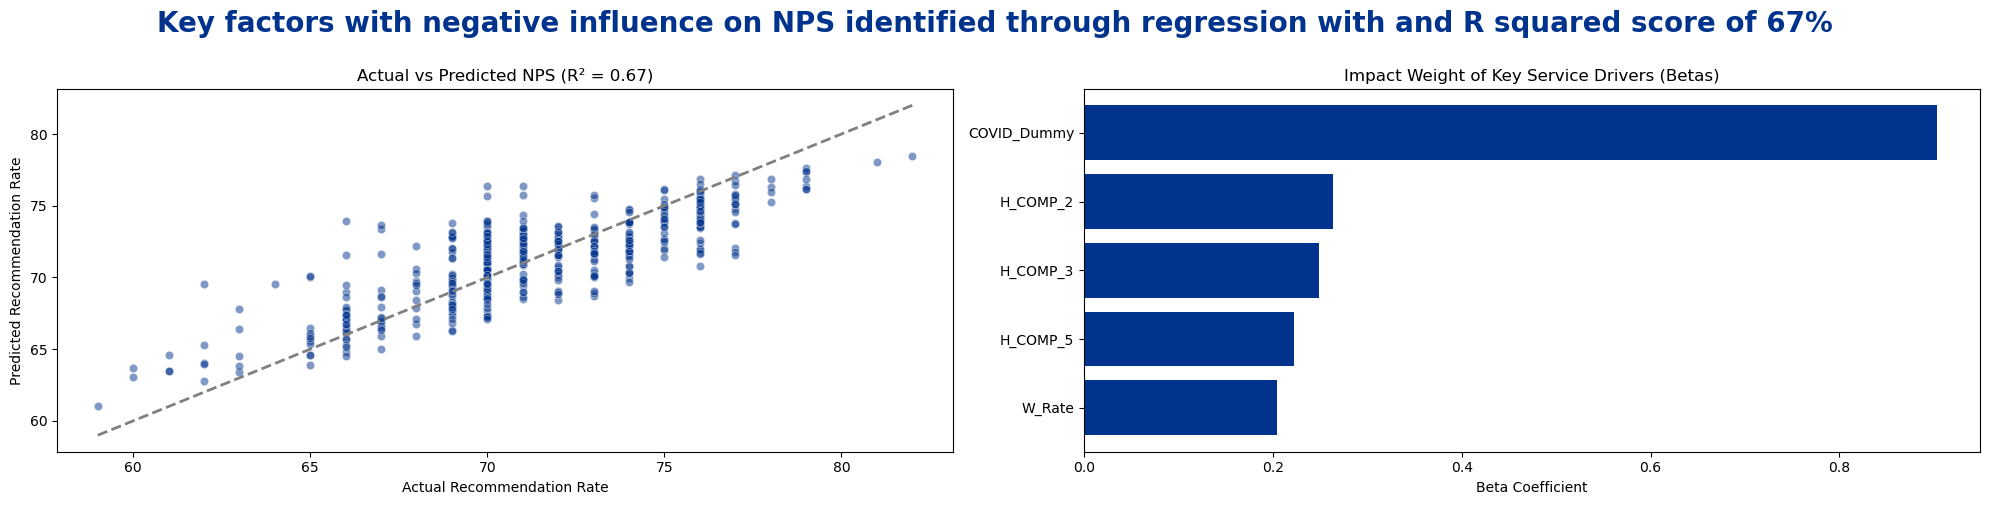

In [165]:
y_pred = lean_model.predict(X_lean)

fig, ax = plt.subplots(1,2, figsize=(20,5))
fig.suptitle("Key factors with negative influence on NPS identified through regression with and R squared score of 67%",x=0.5,y=1,ha="center",fontsize=20,color=blue, fontweight="bold")
sns.scatterplot(x=y, y=y_pred, alpha=0.5, color=blue, ax=ax[0])
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], '--', linewidth=2, color="grey")
ax[0].set_title(f'Actual vs Predicted NPS (R² = {r2_lean:.2f})')
ax[0].set_xlabel('Actual Recommendation Rate'); ax[0].set_ylabel('Predicted Recommendation Rate')

lean_results = lean_results.sort_values(by='Beta', ascending=True)
ax[1].barh(lean_results['Feature'], lean_results['Beta'], color=blue)
ax[1].set_title('Impact Weight of Key Service Drivers (Betas)')
ax[1].set_xlabel('Beta Coefficient')

plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

df = pd.read_csv('state_results.csv')
measures = ['H_HSP_RATING', 'H_COMP_3', 'H_COMP_2', 'H_COMP_5', 'H_RECMND']
filtered_df = df[df['Measure ID'].isin(measures)]

pivoted_df = filtered_df.pivot_table(
    index=['State', 'Release Period'], 
    columns='Measure ID', 
    values='Top-box Percentage'
).dropna()

correlation_results = pivoted_df.corr()['H_RECMND'].drop('H_RECMND')
correlation_df = correlation_results.reset_index()
correlation_df.columns = ['Measure ID', 'Correlation with NPS']
final_results = pd.merge(
    lean_results, 
    correlation_df, 
    left_on='Feature', 
    right_on='Measure ID', 
    how='left'
)

final_results = final_results.rename(columns={'Feature': 'Measures', 'Beta': 'Beta Coefficient'})

names_map = {
    'H_COMP_3': 'Responsiveness of Staff',
    'H_COMP_2': 'Communication with Doctors',
    'H_COMP_5': 'Communication about Medicines',
    'H_HSP_RATING': 'Overall Rating'
}

final_results['Names'] = final_results['Measures'].map(names_map)

final_results = final_results[['Measures', 'Names', 'Beta Coefficient', 'Correlation with NPS']]
final_results.dropna(subset=['Correlation with NPS'], inplace=True)
final_results = final_results.sort_values(by='Correlation with NPS', ascending=False)

final_results

,Measures,Names,Beta Coefficient,Correlation with NPS
2,H_COMP_3,Responsiveness of Staff,0.248634,0.779147
1,H_COMP_5,Communication about Medicines,0.222897,0.753757
3,H_COMP_2,Communication with Doctors,0.263327,0.720532


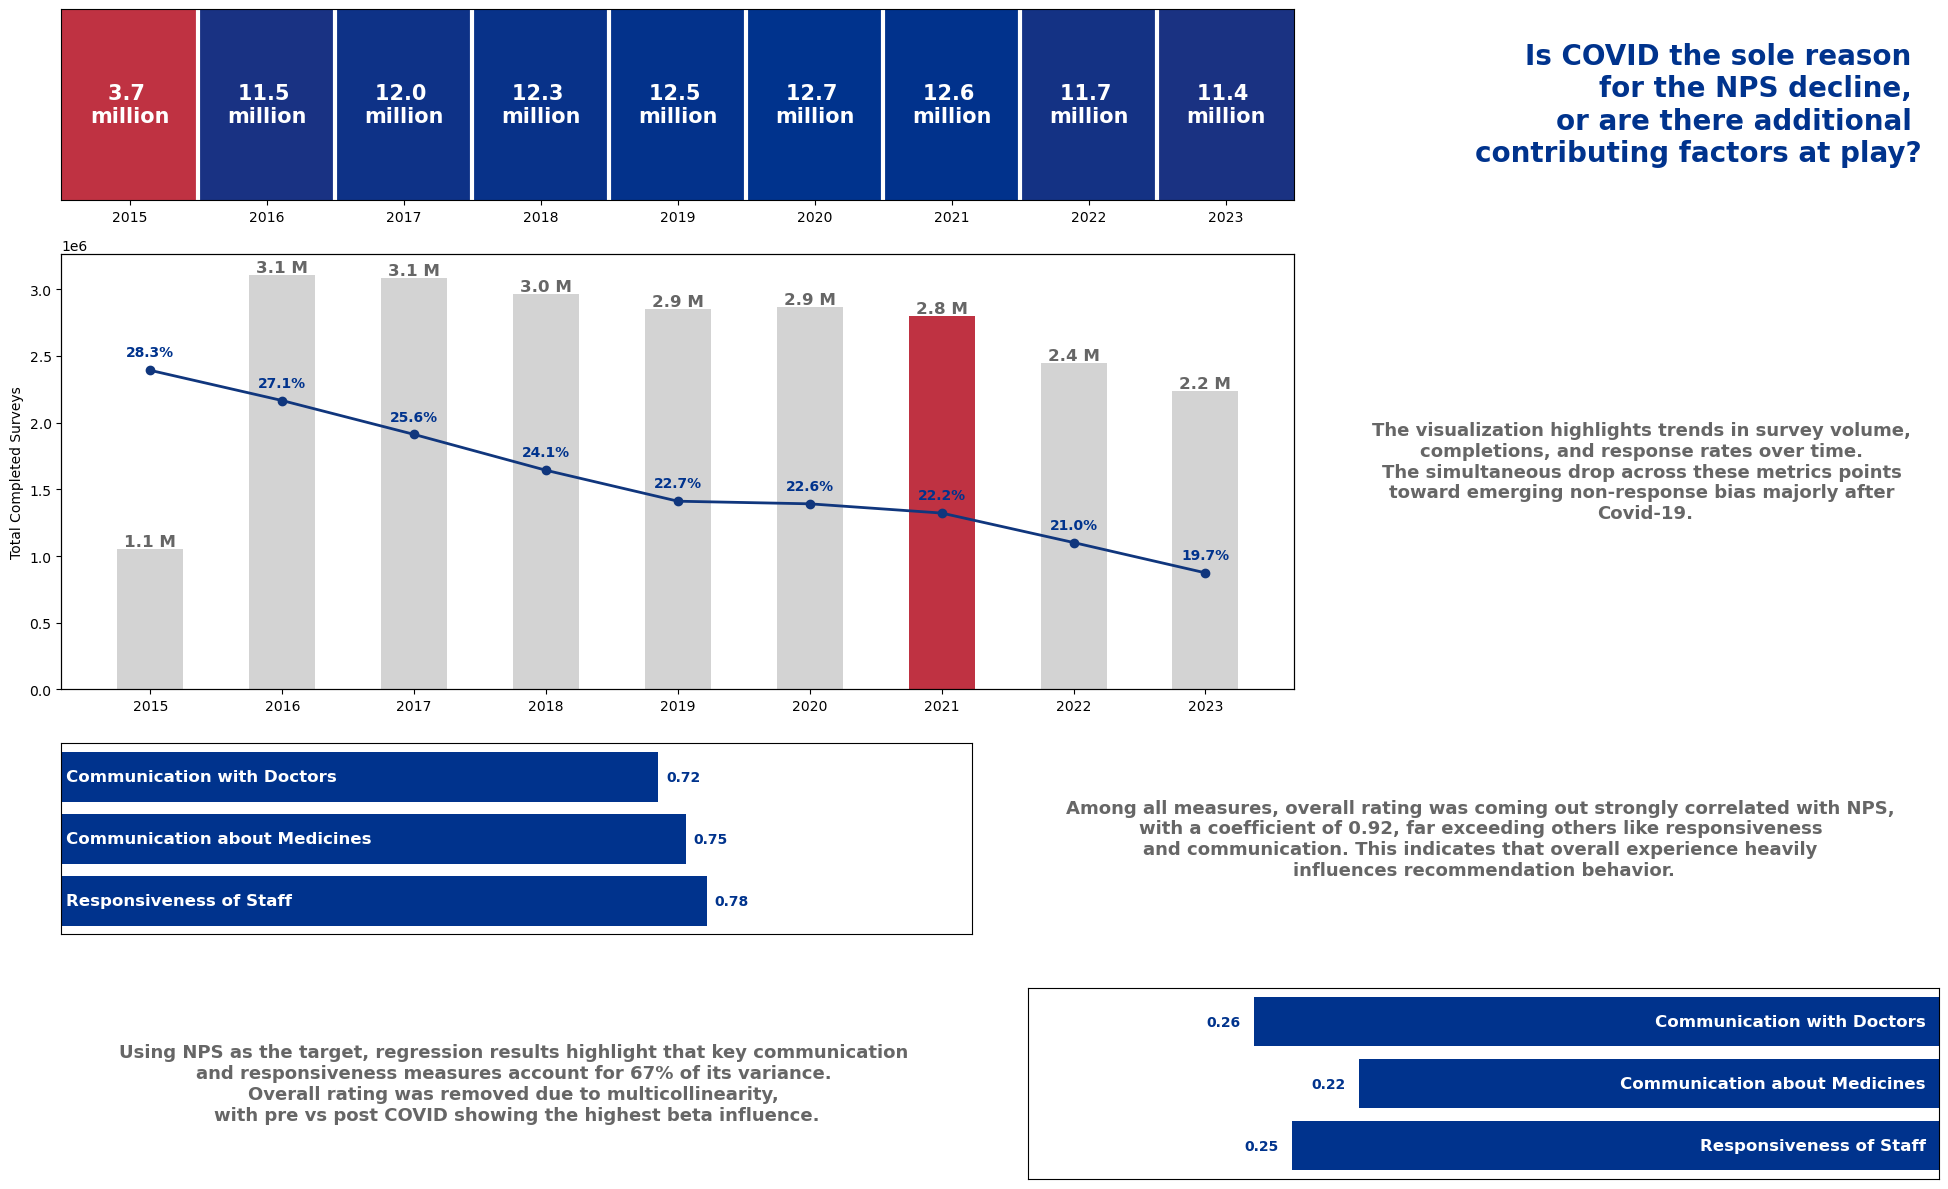

In [177]:
fig = plt.figure(figsize=(20, 12), facecolor="white", dpi=100)
ax1 = plt.subplot2grid((5, 6), (0, 0), colspan=4)                  #correlation plot
data_mailed = (y_stats['Total_Mailed'] / 1e6).round(1).to_frame().T
cmap = mcolors.LinearSegmentedColormap.from_list("custom", [red, blue])
ax1.imshow(data_mailed, cmap=cmap, aspect='auto')
for i, year in enumerate(data_mailed.columns):
    ax1.text(i, 0, f"{data_mailed.iloc[0, i]} \nmillion", ha='center', va='center', color='white', fontweight='bold', fontsize=15)
for i in range(len(data_mailed.columns) - 1):
    ax1.vlines(i + 0.5, -0.5, 0.5, color='white', linewidth=3)
ax1.set_xticks(range(len(data_mailed.columns))); ax1.set_xticklabels(data_mailed.columns)
ax1.set_yticks([])

ax2 = plt.subplot2grid((5, 6), (0, 4), colspan=2)     #empty

ax2.set_yticks([])
ax2.set_xticks([])
ax3 = plt.subplot2grid((5, 6), (1, 0), rowspan=2, colspan=4)          # completed syrvery with response %
colors = [red if int(year) == 2021 else "lightgrey" for year in y_stats.index]
ax3.bar(y_stats.index, y_stats['Total_Completed'], color=colors, width=0.5)
ax3.set_ylabel('Total Completed Surveys')
ax3_twin = ax3.twinx()
ax3_twin.plot(y_stats.index, y_stats['W_Rate'], marker='o', color="#10367d", linewidth=2)
for i, val in enumerate(y_stats['W_Rate']):
    ax3_twin.annotate(f'{val:.1f}%', (y_stats.index[i], y_stats['W_Rate'].iloc[i]), color=blue,
                      textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold')
for i,val in enumerate(y_stats['Total_Completed']): 
    ax3.text(y_stats.index[i], val, f"{val/1e6:.1f} M", ha='center', va='bottom', fontweight='bold',color=grey,fontsize=12)
ax3_twin.set_ylim(y_stats['W_Rate'].min() - 5, y_stats['W_Rate'].max() + 5)
ax3_twin.set_yticks([]); ax3_twin.set_ylabel("")

ax4 = plt.subplot2grid((5, 6), (1, 4), rowspan=2, colspan=2)            # empty
ax4.text(0.5,0.5,"The visualization highlights trends in survey volume, \ncompletions, and response rates over time. \nThe simultaneous drop across these metrics points \ntoward emerging non-response bias majorly after \nCovid-19.",
          va='center',ha="center",color=grey, fontweight='bold',fontsize=13)
ax4.set_yticks([])
ax4.set_xticks([])
ax5 = plt.subplot2grid((5, 6), (3, 0), colspan=3)
bars5 = ax5.barh(final_results["Names"], final_results["Correlation with NPS"], color=blue)
ax5.set_yticks([]);ax5.set_xticks([])
for bar, name, val in zip(bars5, final_results["Names"], final_results["Correlation with NPS"]):
    ax5.text(0.005, bar.get_y() + bar.get_height()/2, name, fontsize=12, va='center', ha='left', color='white', fontweight='bold')
    ax5.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va='center', ha='left', color=blue, fontweight='bold')
ax5.set_xlim(0, 1.1)

ax6 = plt.subplot2grid((5, 6), (3, 3), colspan=3)
ax6.set_xticks([]); ax6.set_yticks([])
ax6.text(0.5, 0.5, "Among all measures, overall rating was coming out strongly correlated with NPS, \nwith a coefficient of 0.92, far exceeding others like responsiveness \nand communication. This indicates that overall experience heavily \ninfluences recommendation behavior.",
         va='center', ha="center", color=grey, fontweight='bold', fontsize=13)

ax7 = plt.subplot2grid((5, 6), (4, 0), colspan=3)
ax7.set_xticks([]); ax7.set_yticks([])
ax7.text(0.5, 0.5, "Using NPS as the target, regression results highlight that key communication \nand responsiveness measures account for 67% of its variance. \nOverall rating was removed due to multicollinearity, \nwith pre vs post COVID showing the highest beta influence.",
         va='center', ha="center", color=grey, fontweight='bold', fontsize=13)

ax8 = plt.subplot2grid((5, 6), (4, 3), colspan=3)
ax8.invert_xaxis()
bars8 = ax8.barh(final_results["Names"], final_results["Beta Coefficient"], color=blue)
ax8.set_yticks([])
for bar, name, val in zip(bars8, final_results["Names"], final_results["Beta Coefficient"]):
    ax8.text(0.005, bar.get_y() + bar.get_height()/2, name, va='center', ha='right', color='white', fontweight='bold', fontsize=12)
    ax8.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va='center', ha='right', color=blue, fontweight='bold')
ax8.set_xlim(0.35, 0)
ax8.set_xticks([])
ax2.text(0.97, 0.5, "Is COVID the sole reason \nfor the NPS decline, \nor are there additional \ncontributing factors at play?",
         fontsize=20, color=blue, ha="right", va="center", fontweight="bold")
for spine in ax2.spines.values(): spine.set_visible(False)
for spine in ax4.spines.values(): spine.set_visible(False)
for spine in ax6.spines.values(): spine.set_visible(False)
for spine in ax7.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.show()

In [114]:
nps_df = state_res[state_res['Measure ID'] == 'H_RECMND'].copy()
nps_df['Year'] = nps_df['Release Period'].str[-4:].astype(int)
pre_covid = nps_df[nps_df['Year'] <= 2020].groupby('State')['Top-box Percentage'].mean()
during_covid = nps_df[nps_df['Year'] >= 2021].groupby('State')['Top-box Percentage'].mean()
state_summary = pd.DataFrame({'Pre_COVID_Mean': pre_covid,'During_COVID_Mean': during_covid}).reset_index()
state_summary['NPS_Difference'] = state_summary['During_COVID_Mean'] - state_summary['Pre_COVID_Mean']
state_summary1 = state_summary.sort_values(by='NPS_Difference')
state_summary1.head()

,State,Pre_COVID_Mean,During_COVID_Mean,NPS_Difference
11,HI,72.333333,67.666667,-4.666667
19,MA,73.666667,71.000000,-2.666667
8,DE,69.333333,66.666667,-2.666667
30,NH,74.166667,71.666667,-2.500000
3,AZ,69.666667,67.333333,-2.333333


In [115]:
nps_df = state_res[state_res['Measure ID'] == 'H_RECMND'].copy()
nps_df['Year'] = nps_df['Release Period'].str[-4:].astype(int)
nat_pre = nps_df[nps_df['Year'] <= 2020]['Top-box Percentage'].mean()
nat_during = nps_df[nps_df['Year'] >= 2021]['Top-box Percentage'].mean()
global_diff = nat_during - nat_pre
print(f"National NPS Pre-COVID: {nat_pre:.2f}")
print(f"National NPS During-COVID: {nat_during:.2f}")
print(f"Global Difference: {global_diff:.2f}")

National NPS Pre-COVID: 71.63
National NPS During-COVID: 70.59
Global Difference: -1.04


In [116]:
state_summary1['color'] = '#32779b'
state_summary1.loc[state_summary1['NPS_Difference'] < -1.02, 'color'] = '#fa8f79'
state_summary1.loc[state_summary1['NPS_Difference'] >= 1, 'color'] = '#00338d'
worst_3_idx = state_summary1.nsmallest(3, 'NPS_Difference').index
state_summary1.loc[worst_3_idx, 'color'] = '#ff5500'

In [118]:
nps_df = state_res[state_res['Measure ID'] == 'H_RECMND'].copy()
nps_df['Year'] = nps_df['Release Period'].str[-4:].astype(int)
pre_covid = nps_df[nps_df['Year'] <= 2020].groupby('State')['Top-box Percentage'].mean()
during_covid = nps_df[nps_df['Year'] >= 2021].groupby('State')['Top-box Percentage'].mean()
state_summary = pd.DataFrame({'NPS Pre Covid': pre_covid,'NPS During Covid': during_covid}).reset_index()
state_summary['Diff in NPS for States'] = state_summary['NPS During Covid'] - state_summary['NPS Pre Covid']
nat_pre = nps_df[nps_df['Year'] <= 2020]['Top-box Percentage'].mean()
nat_during = nps_df[nps_df['Year'] >= 2021]['Top-box Percentage'].mean()
global_diff = nat_during - nat_pre
state_summary['Deviation from National Average'] = state_summary['Diff in NPS for States'] - global_diff

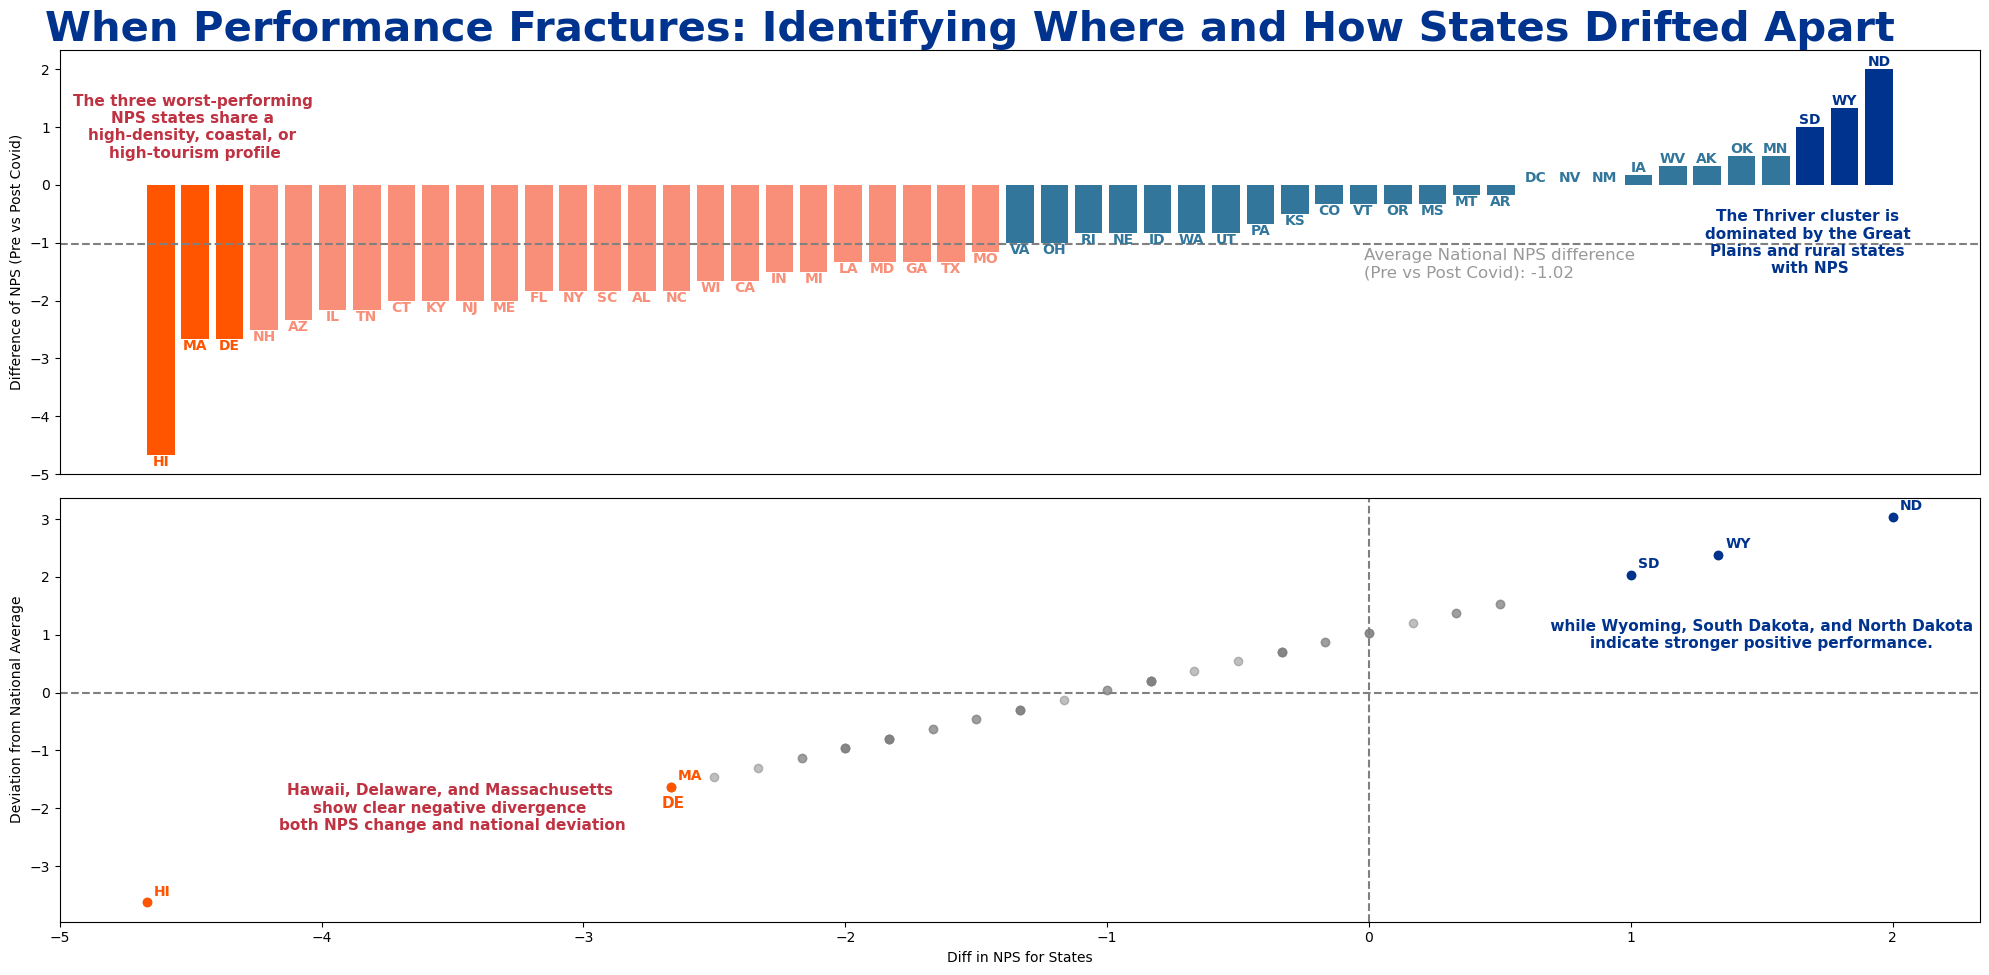

In [166]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10), facecolor="white", dpi=100)
fig.suptitle("When Performance Fractures: Identifying Where and How States Drifted Apart",
             x=0.95,y=0.95,fontsize=30, color=blue, ha="right", va="center", fontweight="bold")
ax1 = plt.subplot2grid((2, 5), (0, 0), colspan=5)
bars = ax1.bar(state_summary1['State'], state_summary1['NPS_Difference'], color=state_summary1['color'])
for bar, state, color in zip(bars, state_summary1['State'], state_summary1['color']):
    height = bar.get_height()
    if height >= 0:
        ax1.text(bar.get_x() + bar.get_width()/2, height, state, ha='center', va='bottom', color=color, fontweight="bold")
    else:
        ax1.text(bar.get_x() + bar.get_width()/2, height, state, ha='center', va='top', color=color, fontweight="bold")
ax1.axhline(-1.02, color='grey', linestyle='--')
ax1.set_xticks([])
ax1.text(35, -1.6, "Average National NPS difference \n(Pre vs Post Covid): -1.02", color="grey", fontsize=12, alpha=0.8)
ax1.set_ylabel("Difference of NPS (Pre vs Post Covid)")
ax2 = plt.subplot2grid((2, 5), (1, 0), colspan=5)
worst_3 = state_summary.nsmallest(2, 'Diff in NPS for States')
best_3 = state_summary.nlargest(3, 'Diff in NPS for States')
ax2.scatter(state_summary['Diff in NPS for States'], state_summary['Deviation from National Average'], color='grey', alpha=0.5)
ax2.scatter(worst_3['Diff in NPS for States'], worst_3['Deviation from National Average'], color='#ff5500')
ax2.scatter(best_3['Diff in NPS for States'], best_3['Deviation from National Average'], color='#00338d')
for df, color in [(worst_3, '#ff5500'), (best_3, '#00338d')]:
    for i in range(len(df)):
        ax2.annotate(df['State'].iat[i], (df['Diff in NPS for States'].iat[i], df['Deviation from National Average'].iat[i]), 
                     xytext=(5, 5), textcoords='offset points', color=color, fontweight="bold")
ax2.axvline(0, color='grey', linestyle='--')
ax2.axhline(0, color='grey', linestyle='--')
ax2.text(-2.7, -2, "DE", color='#ff5500', fontsize=11, fontweight="bold")
ax2.set_xlabel('Diff in NPS for States')
ax2.set_ylabel('Deviation from National Average')
ax1.text(1,1,"The three worst-performing \nNPS states share a \nhigh-density, coastal, or \nhigh-tourism profile",color=red,fontsize=11,fontweight="bold",va="center",ha="center")
ax1.text(48,-1,"The Thriver cluster is \ndominated by the Great \nPlains and rural states \nwith NPS",color=blue,fontsize=11,fontweight="bold",va="center",ha="center")
ax2.text(-3.5,-2,"Hawaii, Delaware, and Massachusetts \nshow clear negative divergence \nboth NPS change and national deviation",color=red,fontsize=11,fontweight="bold",va="center",ha="center")
ax2.text(1.5,1," while Wyoming, South Dakota, and North Dakota \nindicate stronger positive performance.",color=blue,fontsize=11,fontweight="bold",va="center",ha="center")
plt.tight_layout()
plt.tight_layout()
plt.tight_layout()
plt.show()